# EDA + Autocorrelación Espacial — Dengue Perú
**Proyecto Final — Diplomado AI UNI**

**Autor:** Alvaro Untiveros

**Contenido:**
1. Carga y limpieza del consolidado CDC
2. EDA: distribución temporal, distrital y climática
3. Imputación temporal sin romper series
4. Moran's I global — ¿hay clustering espacial? 
    Para justificar la dependencia o independencia de datos y escoger modelo lineal o espacial
5. LISA local — identificación de clusters High-High
6. Feature `cluster_tipo` para los modelos
7. Cross-correlation clima → casos (lags óptimos)

## 0. Imports y configuración

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy import stats

BASE_DIR  = Path('../')
DATA_RAW  = BASE_DIR / 'data' / 'raw'
DATA_INTER= BASE_DIR / 'data' / 'interim'
DATA_INTER.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (13, 4)})
print('Imports OK')

Imports OK


## 1. Carga de datos

In [3]:
# CDC consolidado
df = pd.read_csv(DATA_RAW / 'dengue_consolidado_distrital.csv', low_memory=False)
df['ubigeo'] = df['ubigeo'].astype(str).str.zfill(6)
df['casos']  = df['casos'].fillna(0).astype(int)

# Shapefile distrital
SHP = DATA_RAW / 'geoespacial' / 'Limite Distrital INEI 2025 CPV.shp'
gdf = gpd.read_file(SHP)
gdf['UBIGEO'] = gdf['UBIGEO'].astype(str).str.zfill(6)
gdf = gdf[['UBIGEO', 'DEPARTAMEN', 'DISTRITO', 'geometry']].rename(
    columns={'UBIGEO':'ubigeo','DEPARTAMEN':'departamento','DISTRITO':'distrito_shp'}
)

print(f'CDC   : {df.shape[0]:,} filas | {df["ubigeo"].nunique()} distritos')
print(f'SHP   : {gdf.shape[0]} distritos')
print(f'Años  : {sorted(df["ano"].unique())}')

CDC   : 908,980 filas | 1891 distritos
SHP   : 1891 distritos
Años  : [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]


## 2. EDA
### 2.1 Distribución temporal

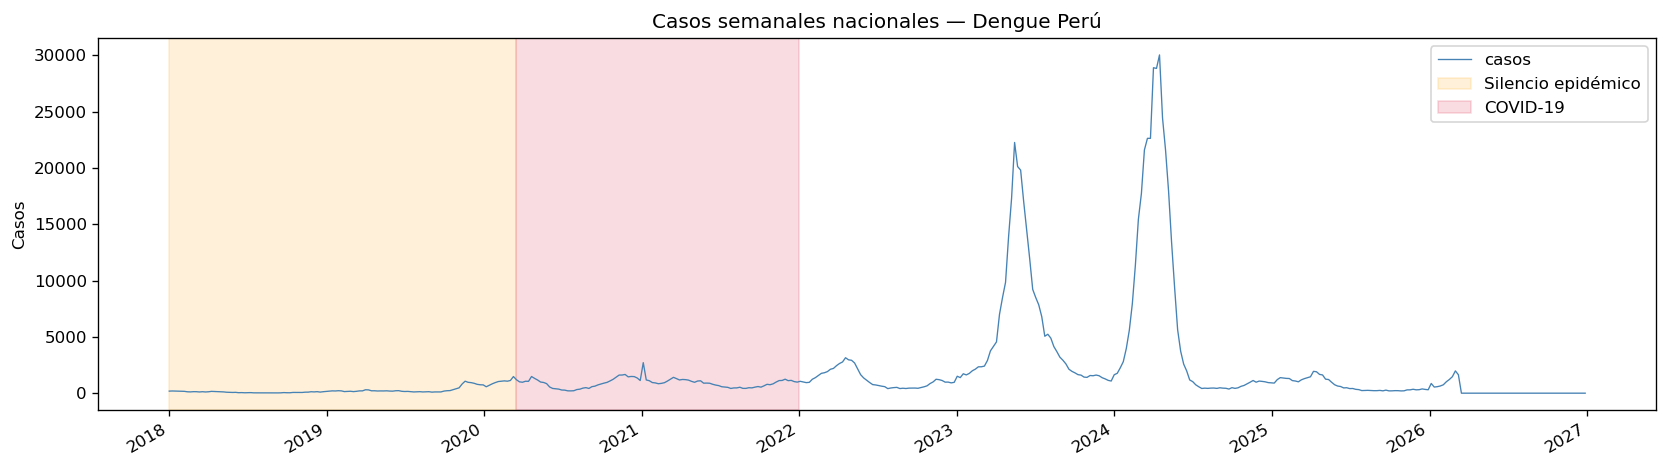

In [4]:
# Fecha sintética (lunes de cada SE de referencia)
df['fecha'] = pd.to_datetime(
    df['ano'].astype(str) + '-' + df['semana_epi'].astype(str) + '-1',
    format='%Y-%W-%w', errors='coerce'
)

casos_sem = df.groupby('fecha')['casos'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
casos_sem.plot(ax=ax, color='steelblue', linewidth=0.8)

ANOMALOS = {
    'Silencio epidémico': ('2018-01-01', '2020-03-14'),
    'COVID-19':           ('2020-03-15', '2022-01-01'),
}
COLORES = {'Silencio epidémico': 'orange', 'COVID-19': 'crimson'}
for label, (ini, fin) in ANOMALOS.items():
    ax.axvspan(ini, fin, alpha=0.15, color=COLORES[label], label=label)
    df.loc[df['fecha'].between(ini, fin), 'flag_anomalia'] = 1
df['flag_anomalia'] = df['flag_anomalia'].fillna(0).astype(int)

ax.set(title='Casos semanales nacionales — Dengue Perú',
       ylabel='Casos', xlabel='')
ax.legend(); plt.tight_layout()

### 2.2 Distribución distrital y sesgo endémico

Endémicos    : 525 (27.8%)
No endémicos : 1366 (72.2%)


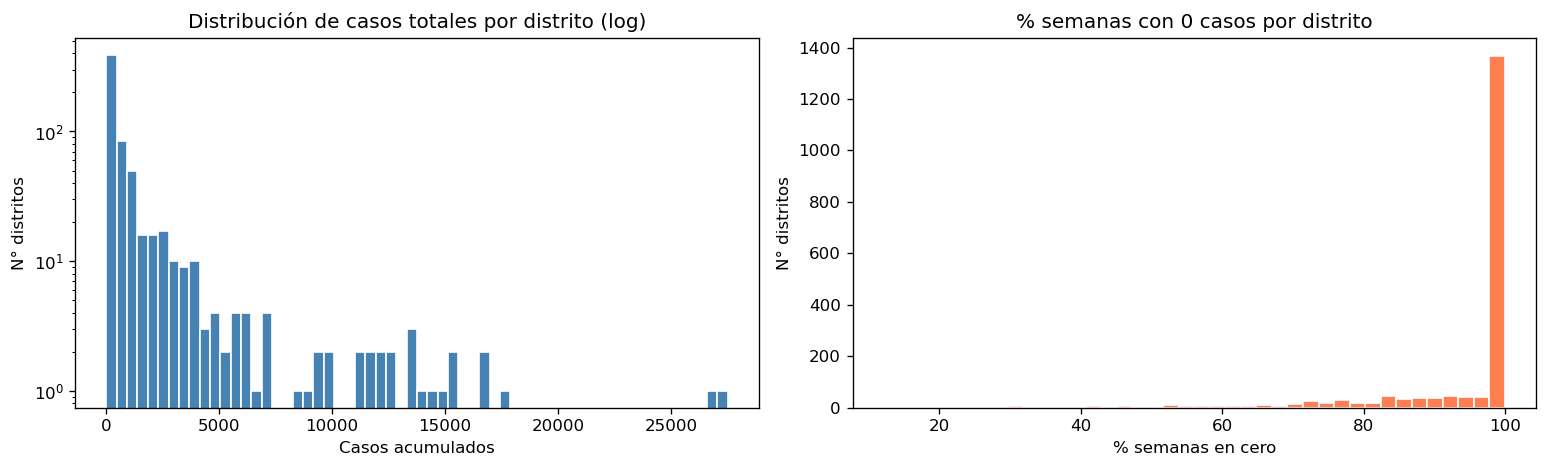

In [5]:
casos_x_dist = df.groupby('ubigeo')['casos'].sum().sort_values(ascending=False)

# Clasificación endémico: ≥10 semanas con al menos 1 caso
se_con_casos = df[df.casos > 0].groupby('ubigeo')['semana_epi'].nunique()
distritos_endemicos = se_con_casos[se_con_casos >= 10].index
df['endemico'] = df['ubigeo'].isin(distritos_endemicos).astype(int)

n_end = len(distritos_endemicos)
n_tot = df['ubigeo'].nunique()
print(f'Endémicos    : {n_end} ({n_end/n_tot*100:.1f}%)')
print(f'No endémicos : {n_tot - n_end} ({(n_tot-n_end)/n_tot*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

casos_x_dist[casos_x_dist > 0].plot(
    kind='hist', bins=60, logy=True, ax=axes[0],
    color='steelblue', edgecolor='white'
)
axes[0].set(title='Distribución de casos totales por distrito (log)',
            xlabel='Casos acumulados', ylabel='N° distritos')

pct_ceros = df.groupby('ubigeo').apply(lambda g: (g['casos']==0).mean()*100)
pct_ceros.plot(kind='hist', bins=40, ax=axes[1], color='coral', edgecolor='white')
axes[1].set(title='% semanas con 0 casos por distrito',
            xlabel='% semanas en cero', ylabel='N° distritos')
plt.tight_layout()

### 2.3 Mapa de casos acumulados

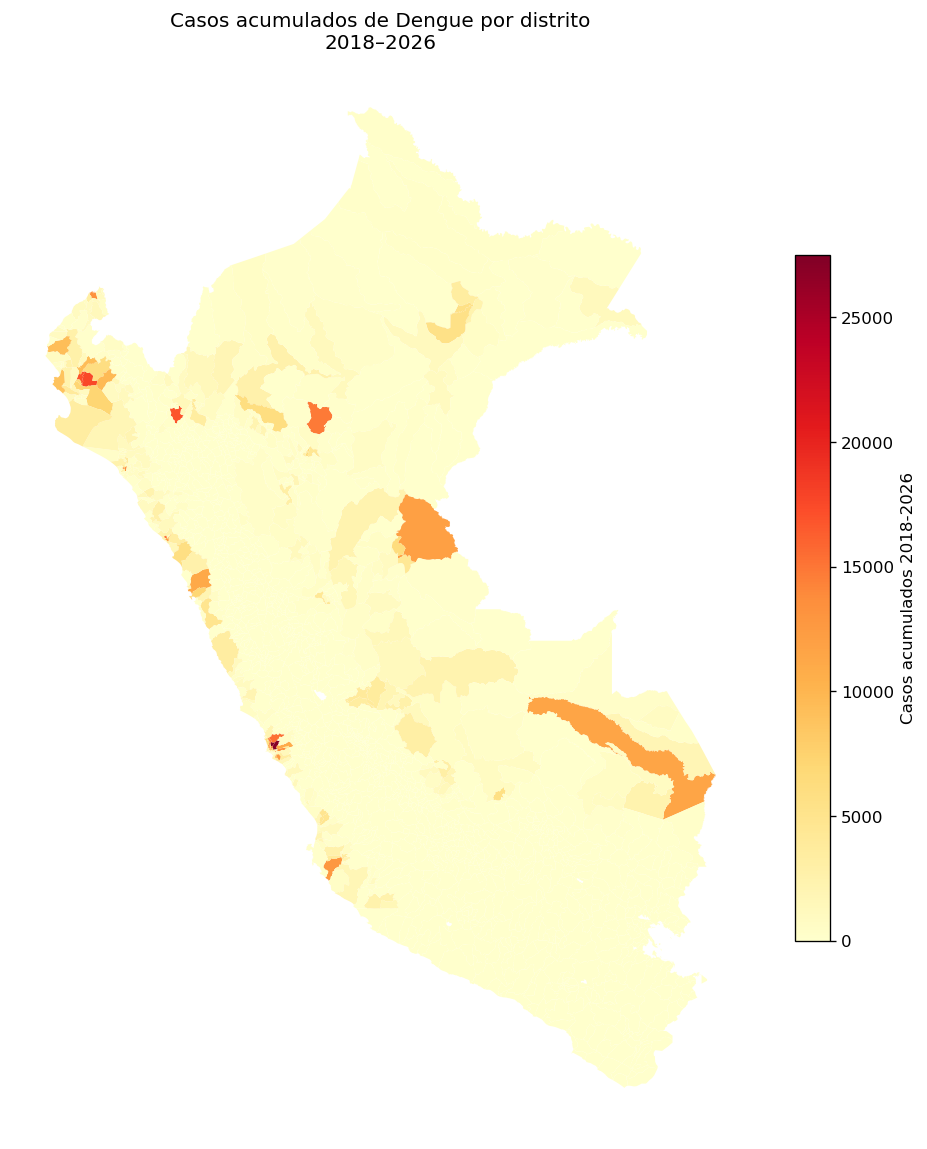

In [7]:
casos_acum = df.groupby('ubigeo')['casos'].sum().reset_index()
casos_acum.columns = ['ubigeo', 'casos_acum']

gdf_casos = gdf.merge(casos_acum, on='ubigeo', how='left')
gdf_casos['casos_acum'] = gdf_casos['casos_acum'].fillna(0)

fig, ax = plt.subplots(1, 1, figsize=(8, 10))
gdf_casos.plot(
    column='casos_acum', ax=ax, cmap='YlOrRd',
    legend=True, missing_kwds={'color':'lightgrey'},
    legend_kwds={'label': 'Casos acumulados 2018-2026', 'shrink': 0.6}
)
ax.set_title('Casos acumulados de Dengue por distrito\n2018–2026')
ax.axis('off')
plt.tight_layout()

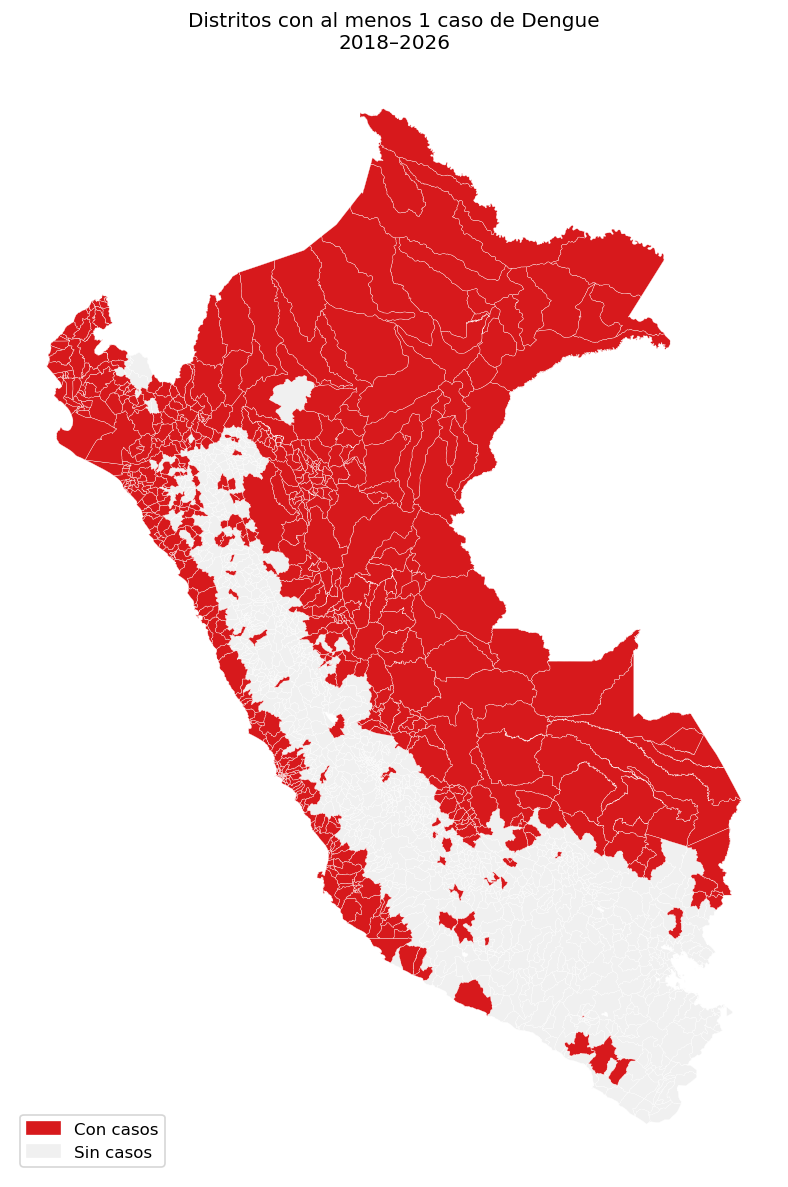

In [10]:
# Mapa binario — con/sin casos (comparable al reporte CDC)
gdf_casos['tiene_casos'] = (gdf_casos['casos_acum'] > 0).astype(int)

fig, ax = plt.subplots(figsize=(8, 10))
gdf_casos[gdf_casos.tiene_casos == 0].plot(
    ax=ax, color='#f0f0f0', linewidth=0.2, edgecolor='white'
)
gdf_casos[gdf_casos.tiene_casos == 1].plot(
    ax=ax, color='#d7191c', linewidth=0.2, edgecolor='white'
)
ax.set(title='Distritos con al menos 1 caso de Dengue\n2018–2026')
ax.axis('off')

# Leyenda manual
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#d7191c', label='Con casos'),
    Patch(color='#f0f0f0', label='Sin casos'),
], loc='lower left')
plt.tight_layout()

### 2.4 Outliers — detección IQR

In [8]:
VARS_CLIMA = [c for c in ['tmean_clima','tmax_clima','tmin_clima','humr_clima','ptot_clima']
              if c in df.columns]

def outliers_iqr(serie, k=3.0):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return ((serie < Q1 - k*IQR) | (serie > Q3 + k*IQR)).sum()

reporte = {v: outliers_iqr(df[v].dropna()) for v in VARS_CLIMA + ['casos']}
pd.Series(reporte, name='n_outliers').to_frame()

,n_outliers
tmean_clima,0
tmax_clima,0
tmin_clima,0
humr_clima,3681
ptot_clima,16226
casos,58120


## 3. Imputación temporal
Interpolación lineal dentro de cada distrito + ffill/bfill para extremos.  
**No se usa media global** — preserva la estructura temporal para LSTM.

### Justificación de la estrategia de imputación

Las variables climáticas del CDC (`tmean_clima`, `tmax_clima`, etc.) presentan
nulos por dos razones: (1) semanas sin datos de estaciones meteorológicas cercanas
al distrito, y (2) distritos sin ninguna cobertura de estación en todo el período.

**Estrategia elegida: interpolación lineal temporal por distrito + ffill/bfill**

Para cada distrito, los valores faltantes intermedios se estiman asumiendo
variación lineal entre el valor anterior y el siguiente conocido. Los extremos
(inicio o fin de serie sin datos) se rellenan con el valor más cercano disponible
(forward/backward fill).

Esta estrategia es adecuada porque:
- Las variables climáticas tienen **autocorrelación temporal alta** — la temperatura
  de la semana 10 es predecible a partir de las semanas 9 y 11.
- **Preserva la estructura temporal** de la serie, condición necesaria para que
  LSTM y modelos de lags no aprendan discontinuidades artificiales.
- Es computacionalmente simple y reproducible sin hiperparámetros que tunear.

Los **10,810 nulos restantes** corresponden a distritos con cobertura climática
cero en todo el período — en esos casos la interpolación no puede operar.
Para el modelo usaremos `CHIRPS` (precipitación) y `LST` de MODIS como
variables satelitales alternativas con cobertura espacial completa.

In [9]:
df = df.sort_values(['ubigeo', 'fecha'])

for var in VARS_CLIMA:
    df[var] = (
        df.groupby('ubigeo')[var]
        .transform(lambda s: s.interpolate(method='linear').ffill().bfill())
    )

nulos_post = df[VARS_CLIMA].isnull().sum()
print('Nulos restantes tras imputación:')
print(nulos_post.to_string())

Nulos restantes tras imputación:
tmean_clima    10810
tmax_clima     10810
tmin_clima     10810
humr_clima     10810
ptot_clima         0


## 4. Test de Moran's I Global

El **Índice de Moran's I** mide si los valores similares tienden a agruparse espacialmente.

$$I = \frac{n}{\sum_i \sum_j w_{ij}} \cdot \frac{\sum_i \sum_j w_{ij}(x_i - \bar{x})(x_j - \bar{x})}{\sum_i (x_i - \bar{x})^2}$$

Donde $w_{ij}$ es la matriz de pesos espaciales (contigüidad Queen).  
- $I > 0$: clustering positivo (distritos con brotes rodeados de distritos con brotes)
- $I \approx 0$: distribución aleatoria
- $I < 0$: dispersión espacial

**Hipótesis nula:** distribución espacialmente aleatoria ($p > 0.05$).

In [13]:
from libpysal.weights import Queen
from esda.moran import Moran

# Usar tasa por SE promedio (más estable que casos absolutos)
casos_por_distrito = (
    df[df.flag_anomalia == 0]  # excluir períodos anómalos del cálculo
    .groupby('ubigeo')['casos']
    .mean()
    .reset_index()
    .rename(columns={'casos': 'casos_media_se'})
)

gdf_moran = gdf.merge(casos_por_distrito, on='ubigeo', how='left')
gdf_moran['casos_media_se'] = gdf_moran['casos_media_se'].fillna(0)

# Matriz de pesos Queen (contigüidad compartiendo borde o vértice)
w = Queen.from_dataframe(gdf_moran, silence_warnings=True)
w.transform = 'r'  # estandarización por fila

# Test de Moran's I
moran = Moran(gdf_moran['casos_media_se'], w, permutations=999)

print(f'Moran I  : {moran.I:.4f}')
print(f'p-valor  : {moran.p_sim:.4f}')
print(f'z-score  : {moran.z_sim:.4f}')
print()
if moran.p_sim < 0.05:
    if moran.I > 0:
        print('Clustering espacial significativo — distritos con brotes se agrupan')
    else:
        print('Dispersión espacial significativa')
else:
    print('X Sin autocorrelación espacial significativa (distribución aleatoria)')

Moran I  : 0.4397
p-valor  : 0.0010
z-score  : 32.5266

Clustering espacial significativo — distritos con brotes se agrupan


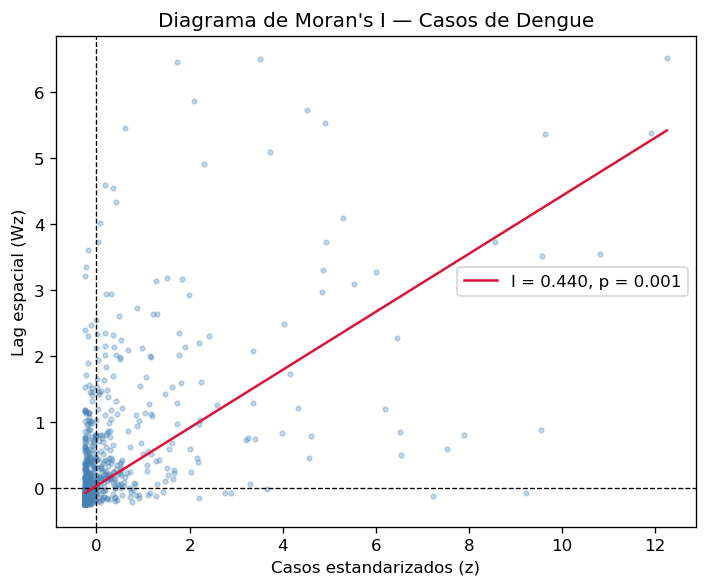

In [14]:
# Diagrama de dispersión de Moran
fig, ax = plt.subplots(figsize=(6, 5))

y     = gdf_moran['casos_media_se'].values
y_lag = moran.z_sim  # lag espacial estandarizado

# Usar la variable estandarizada
from esda.moran import Moran
import libpysal

y_std   = (y - y.mean()) / y.std()
wy_std  = libpysal.weights.lag_spatial(w, y_std)

ax.scatter(y_std, wy_std, alpha=0.3, s=8, color='steelblue')
ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
ax.axvline(0, color='k', linewidth=0.8, linestyle='--')

# Línea de regresión (pendiente = I de Moran)
m, b = np.polyfit(y_std, wy_std, 1)
x_line = np.linspace(y_std.min(), y_std.max(), 100)
ax.plot(x_line, m*x_line + b, color='crimson', linewidth=1.5,
        label=f'I = {moran.I:.3f}, p = {moran.p_sim:.3f}')

ax.set(title="Diagrama de Moran's I — Casos de Dengue",
       xlabel='Casos estandarizados (z)', ylabel='Lag espacial (Wz)')
ax.legend(); plt.tight_layout()

## 5. LISA — Moran's I Local

El **Local Indicators of Spatial Association (LISA)** descompone el Moran's I global en contribuciones por distrito, identificando 4 tipos de clusters:

| Cuadrante | Tipo | Interpretación |
|-----------|------|----------------|
| HH | High-High | Distrito con brotes, rodeado de distritos con brotes — **foco endémico** |
| LL | Low-Low | Distrito sin brotes, rodeado de distritos sin brotes — zona limpia |
| HL | High-Low | Outlier espacial — brote aislado |
| LH | Low-High | Outlier espacial — bajo riesgo en zona endémica |

In [15]:
from esda.moran import Moran_Local

lisa = Moran_Local(gdf_moran['casos_media_se'], w,
                   permutations=999, seed=42)

# Asignar tipo de cluster (solo significativos p<0.05)
sig  = lisa.p_sim < 0.05
quad = lisa.q  # 1=HH, 2=LH, 3=LL, 4=HL

QUAD_LABELS = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
QUAD_COLORS = {'HH': '#d7191c', 'LH': '#abd9e9',
               'LL': '#2c7bb6', 'HL': '#fdae61', 'ns': '#eeeeee'}

gdf_moran['lisa_cluster'] = 'ns'
for i, (s, q) in enumerate(zip(sig, quad)):
    if s:
        gdf_moran.iloc[i, gdf_moran.columns.get_loc('lisa_cluster')] = QUAD_LABELS[q]

conteo = gdf_moran['lisa_cluster'].value_counts()
print('Distribución de clusters LISA:')
print(conteo.to_string())

Distribución de clusters LISA:
lisa_cluster
ns    1225
LL     539
HH      94
LH      33


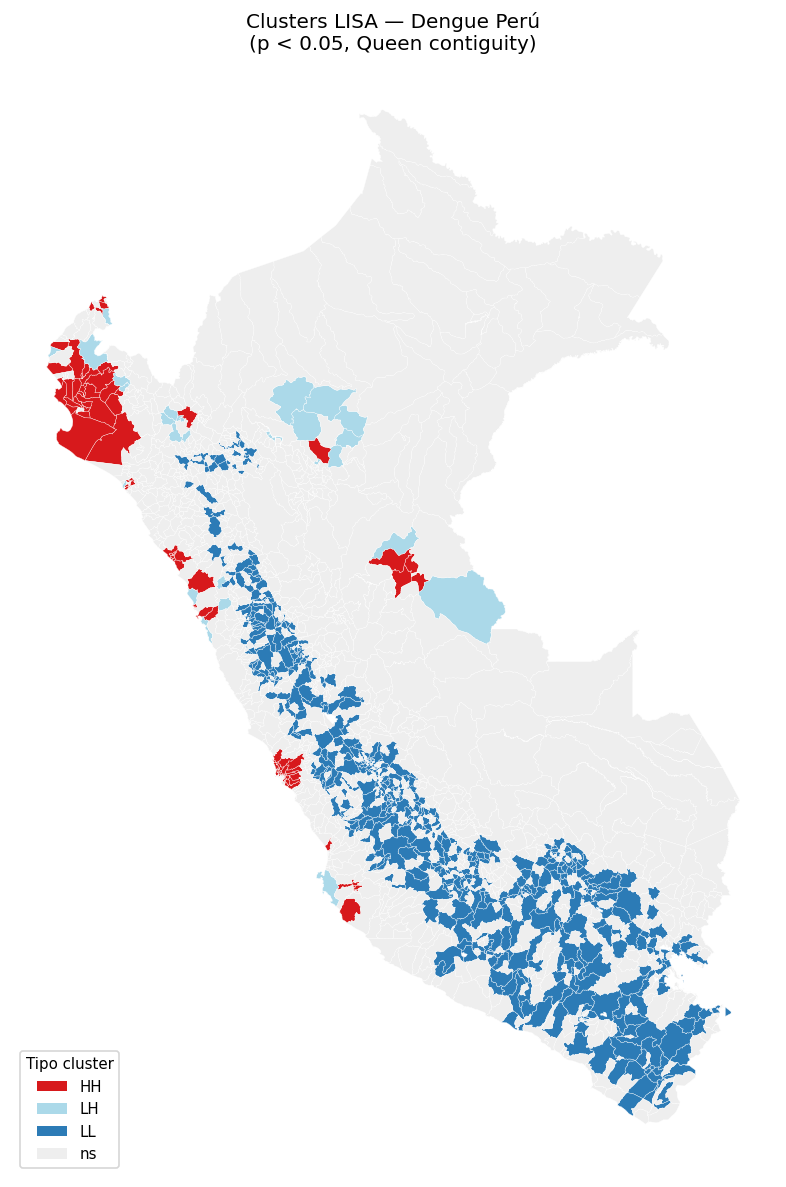

In [19]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 10))

for tipo, color in QUAD_COLORS.items():
    subset = gdf_moran[gdf_moran['lisa_cluster'] == tipo]
    if not subset.empty:
        subset.plot(ax=ax, color=color, linewidth=0.2, edgecolor='white')

# Leyenda manual — solo los tipos que existen en los datos
handles = [
    Patch(facecolor=QUAD_COLORS[t], label=t)
    for t in QUAD_COLORS
    if t in gdf_moran['lisa_cluster'].values
]
ax.legend(handles=handles, title='Tipo cluster',
          loc='lower left', fontsize=9, title_fontsize=9)

ax.set(title='Clusters LISA — Dengue Perú\n(p < 0.05, Queen contiguity)')
ax.axis('off')
plt.tight_layout()

## 6. Feature `cluster_tipo` para los modelos
Incorporamos el resultado LISA como variable estática por distrito.

In [17]:
# Codificación ordinal del cluster para los modelos
CLUSTER_CODE = {'HH': 4, 'HL': 3, 'LH': 2, 'LL': 1, 'ns': 0}

cluster_feat = gdf_moran[['ubigeo', 'lisa_cluster']].copy()
cluster_feat['cluster_code'] = cluster_feat['lisa_cluster'].map(CLUSTER_CODE)

# Merge al dataframe principal
df = df.merge(cluster_feat[['ubigeo','lisa_cluster','cluster_code']],
              on='ubigeo', how='left')
df['cluster_code'] = df['cluster_code'].fillna(0).astype(int)

print('Feature cluster_tipo agregada al dataset:')
print(df[['ubigeo','lisa_cluster','cluster_code']]
      .drop_duplicates('ubigeo')
      .value_counts('lisa_cluster')
      .to_string())

Feature cluster_tipo agregada al dataset:
lisa_cluster
ns    1225
LL     539
HH      94
LH      33


## 7. Cross-correlation clima → casos

Calculamos el lag óptimo para cada variable climática a nivel departamental.  
El lag óptimo es el desfase $k$ que maximiza $Corr(casos_t, clima_{t-k})$.

In [22]:
MAX_LAG = 26

# Solo departamentos con suficientes casos para que la correlación sea confiable
casos_x_depto = df.groupby('departamento')['casos'].sum()
DEPTOS_ENDEMICOS = casos_x_depto[casos_x_depto > 500].index.tolist()
print(f'Departamentos endémicos seleccionados: {len(DEPTOS_ENDEMICOS)}')
print(DEPTOS_ENDEMICOS)

resultados_lag = []
for depto in DEPTOS_ENDEMICOS:
    sub = (
        df[(df['departamento'] == depto) & (df['flag_anomalia'] == 0)]
        .groupby('fecha')[VARS_CLIMA_BASE + ['casos']]
        .mean()
        .sort_index()
    )
    if len(sub) < MAX_LAG * 2:  # mínimo de datos para que tenga sentido
        continue
    for var in VARS_CLIMA_BASE:
        lags_corr = []
        for lag in range(0, MAX_LAG + 1):
            shifted = sub[var].shift(lag)
            mask = sub['casos'].notna() & shifted.notna()
            if mask.sum() < 20:
                lags_corr.append(0)
                continue
            r, _ = stats.pearsonr(sub['casos'][mask], shifted[mask])
            lags_corr.append(abs(r))
        lag_opt = int(np.argmax(lags_corr))
        resultados_lag.append({
            'departamento': depto,
            'variable': var,
            'lag_optimo': lag_opt,
            'correlacion': round(max(lags_corr), 3)
        })

df_lags = pd.DataFrame(resultados_lag)
print('\nLags óptimos promedio por variable:')
print(df_lags.groupby('variable')['lag_optimo']
      .agg(['mean','median','std'])
      .round(1)
      .to_string())

Departamentos endémicos seleccionados: 21
['AMAZONAS', 'ANCASH', 'AYACUCHO', 'CAJAMARCA', 'CALLAO', 'CUSCO', 'HUANUCO', 'ICA', 'JUNIN', 'LA LIBERTAD', 'LAMBAYEQUE', 'LIMA', 'LIMA METROPOLITANA', 'LORETO', 'MADRE DE DIOS', 'PASCO', 'PIURA', 'PUNO', 'SAN MARTIN', 'TUMBES', 'UCAYALI']

Lags óptimos promedio por variable:
             mean  median  std
variable                      
humr_clima   12.2     9.0  8.9
ptot_clima    8.4     9.0  6.1
tmean_clima  10.6     9.0  5.3
tmin_clima   10.8     8.0  8.1


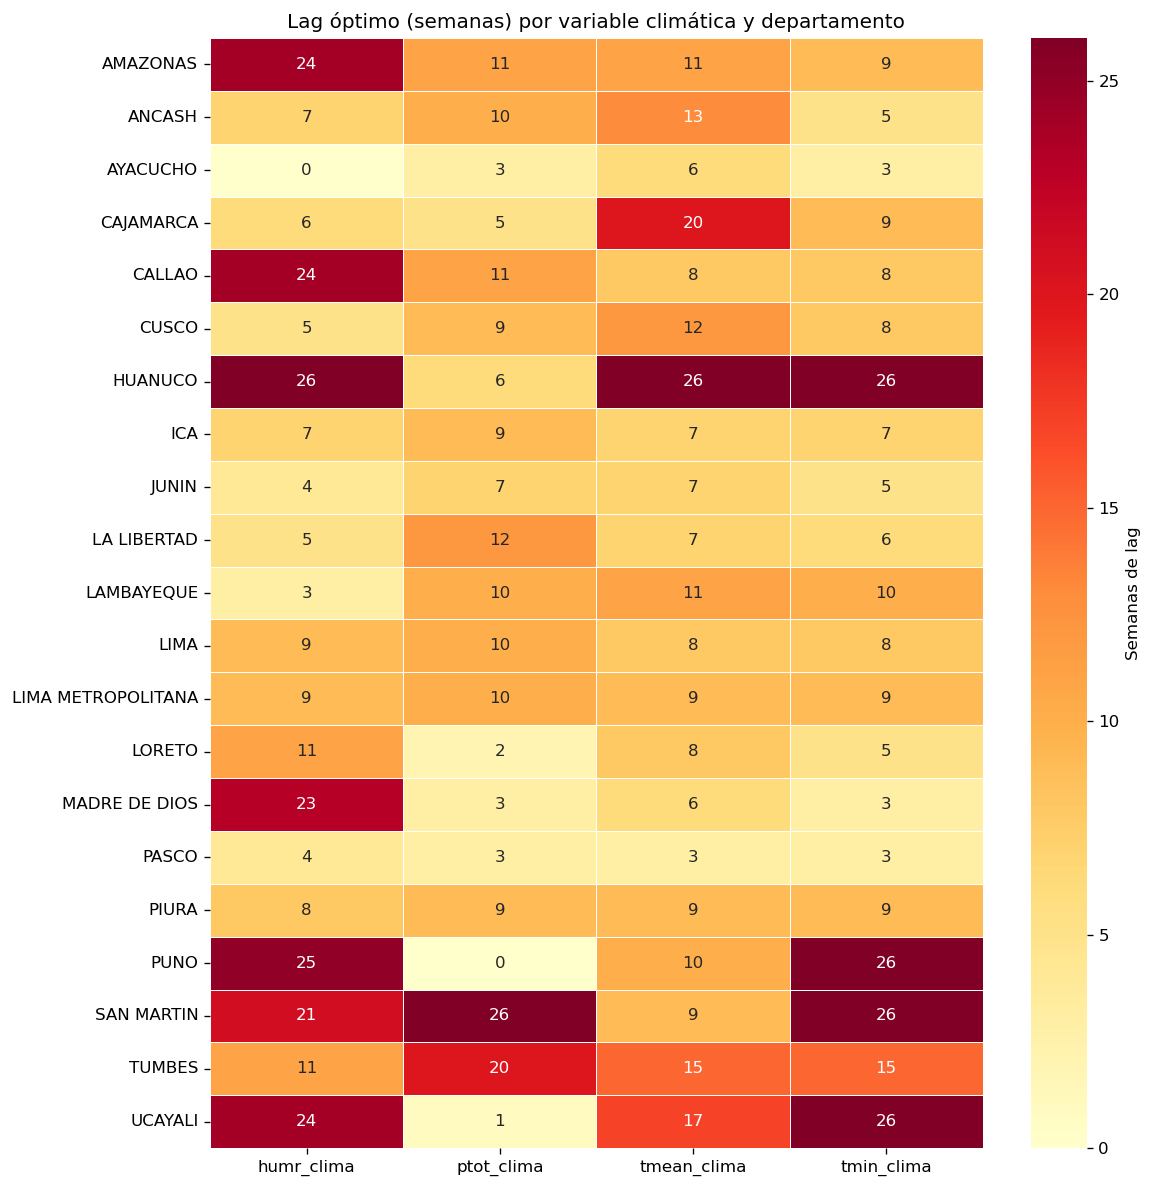

In [23]:
# Heatmap de lags por departamento
pivot = df_lags.pivot_table(
    index='departamento', columns='variable', values='lag_optimo'
)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Semanas de lag'})
ax.set(title='Lag óptimo (semanas) por variable climática y departamento',
       xlabel='', ylabel='')
plt.tight_layout()

## 8. Guardar dataset limpio + features espaciales

In [24]:
out_path = DATA_INTER / 'dengue_limpio_con_espacial.parquet'
df.to_parquet(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'  Shape  : {df.shape}')
print(f'  Columnas nuevas: flag_anomalia, endemico, lisa_cluster, cluster_code')

# Guardar también los lags para usarlos en feature engineering
df_lags.to_csv(DATA_INTER / 'lags_optimos_departamental.csv', index=False)
print('Guardado: lags_optimos_departamental.csv')

Guardado: D:\Universidad\Alvaro\Proyecto UNI\UNI\Proyecto\data\interim\dengue_limpio_con_espacial.parquet
  Shape  : (908980, 23)
  Columnas nuevas: flag_anomalia, endemico, lisa_cluster, cluster_code
Guardado: lags_optimos_departamental.csv


**Nota:** El análisis de lags se realizó a nivel departamental para garantizar
series temporales con suficiente variabilidad estadística. A nivel distrital,
el alto porcentaje de semanas con cero casos (~95% en distritos no endémicos)
produce correlaciones espurias. Como trabajo futuro se propone realizar el
análisis a nivel distrital restringiéndolo a los 94 distritos HH identificados
por LISA, donde las series son suficientemente densas.